In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv("../data/raw/diabetes/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 768
Number of columns: 9


In [6]:
print(df.columns.tolist())

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [9]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [10]:
print(df["Outcome"].value_counts())
print(df["Outcome"].value_counts(normalize=True) * 100)

Outcome
0    500
1    268
Name: count, dtype: int64
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


In [11]:
zero_counts = (df == 0).sum()

print(zero_counts)

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


In [12]:
medical_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

zero_counts_medical = (df[medical_columns] == 0).sum()

print(zero_counts_medical)

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [13]:
zero_percentage = (
    (df[medical_columns] == 0).mean() * 100
).round(2)

print(zero_percentage)

Glucose           0.65
BloodPressure     4.56
SkinThickness    29.56
Insulin          48.70
BMI               1.43
dtype: float64


In [14]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [15]:
df.groupby("Outcome").mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


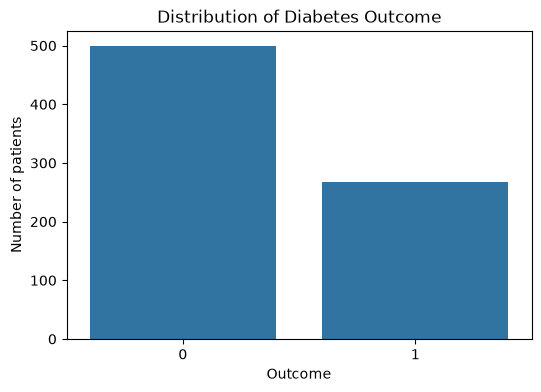

In [16]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Outcome")

plt.title("Distribution of Diabetes Outcome")
plt.xlabel("Outcome")
plt.ylabel("Number of patients")

plt.show()

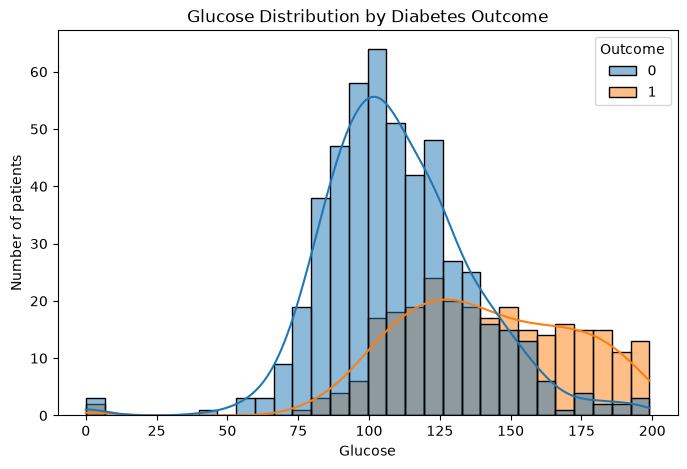

In [17]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Glucose",
    hue="Outcome",
    kde=True,
    bins=30
)

plt.title("Glucose Distribution by Diabetes Outcome")
plt.xlabel("Glucose")
plt.ylabel("Number of patients")

plt.show()

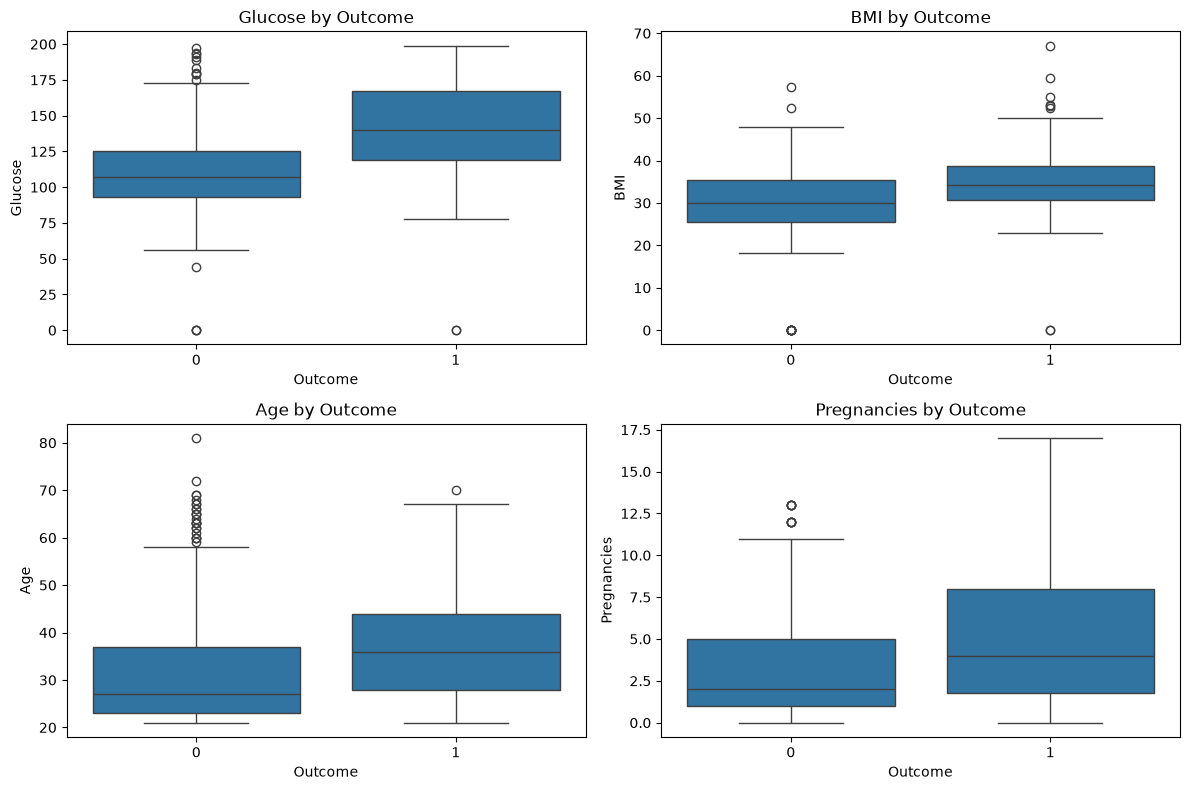

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.boxplot(data=df, x="Outcome", y="Glucose", ax=axes[0, 0])
axes[0, 0].set_title("Glucose by Outcome")

sns.boxplot(data=df, x="Outcome", y="BMI", ax=axes[0, 1])
axes[0, 1].set_title("BMI by Outcome")

sns.boxplot(data=df, x="Outcome", y="Age", ax=axes[1, 0])
axes[1, 0].set_title("Age by Outcome")

sns.boxplot(data=df, x="Outcome", y="Pregnancies", ax=axes[1, 1])
axes[1, 1].set_title("Pregnancies by Outcome")

plt.tight_layout()
plt.show()

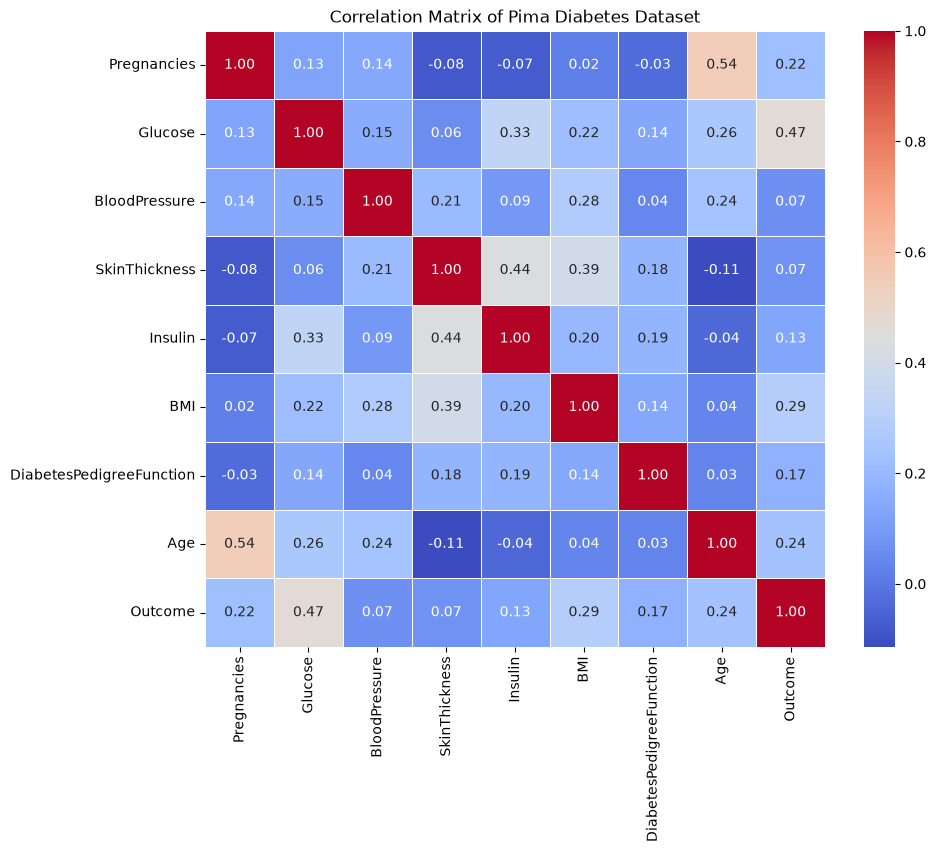

In [21]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Pima Diabetes Dataset")
plt.show()

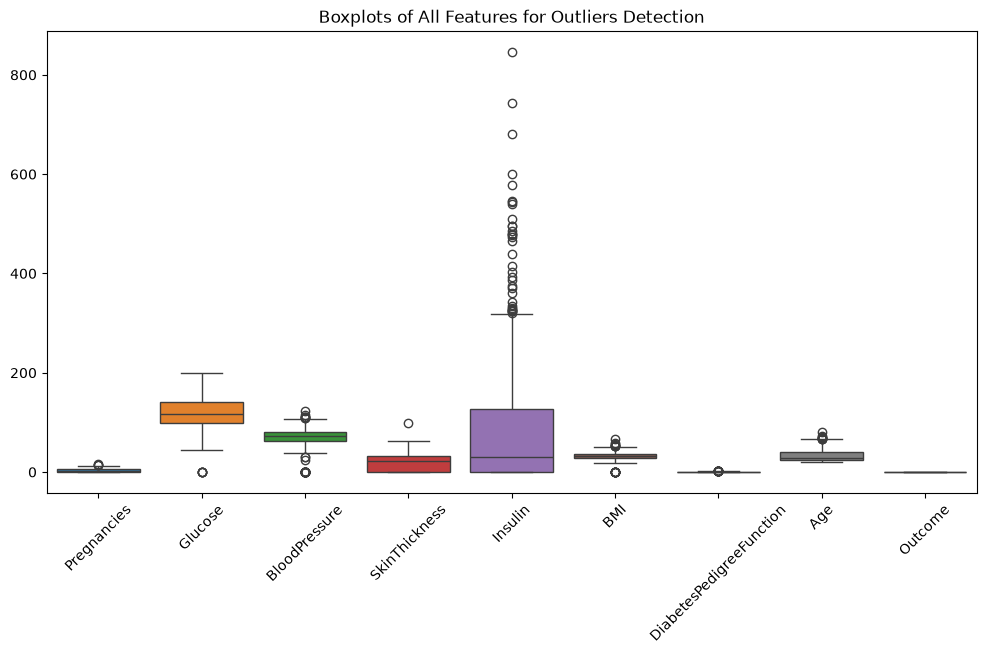

In [22]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Boxplots of All Features for Outliers Detection")
plt.show()

## Key Insights from EDA:
1. **Target Distribution**: The dataset is imbalanced, with ~65% non-diabetic (0) and ~35% diabetic (1) patients.
2. **Key Predictors**: **Glucose** shows the strongest positive correlation ($\approx 0.47$) and a clear distributional shift between diabetic and non-diabetic patients. **BMI** and **Age** are also moderately correlated with the outcome.
3. **Data Anomalies / Outliers**: Several medical variables (Glucose, BloodPressure, SkinThickness, Insulin, BMI) contain physical zeros which represent missing/corrupted data that need careful handling during preprocessing. **Insulin** and **Pregnancies** display significant outliers.

In [23]:
import numpy as np

# 1. Liste des colonnes où 0 est une valeur aberrante (impossible médicalement)
columns_with_zeros = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# 2. Remplacer les 0 par des NaN
df[columns_with_zeros] = df[columns_with_zeros].replace(0, np.nan)

# 3. Vérifier le nombre de NaN générés
print("Nombre de valeurs manquantes (NaN) après remplacement :")
print(df.isnull().sum())

# 4. Imputer les NaN par la médiane de chaque colonne
for col in columns_with_zeros:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)

# 5. Vérification finale : est-ce qu'il reste des zéros ou des NaN ?
print("\nNombre de valeurs manquantes après imputation :")
print(df.isnull().sum())

Nombre de valeurs manquantes (NaN) après remplacement :
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Nombre de valeurs manquantes après imputation :
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


/tmp/ipykernel_15216/1982125573.py:16: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(median_val, inplace=True)
/tmp/ipykernel_15216/1982125573.py:16: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to upd

In [24]:
from sklearn.model_selection import train_test_split

# 1. Séparation des features (X) et de la target (y)
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

# 2. Division en jeu d'entraînement (80%) et jeu de test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Vérification des dimensions
print(f"Dimensions de X_train : {X_train.shape}")
print(f"Dimensions de X_test  : {X_test.shape}")

Dimensions de X_train : (614, 8)
Dimensions de X_test  : (154, 8)


In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Initialisation du modèle Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Entraînement sur le jeu d'entraînement
rf_model.fit(X_train, y_train)

# 3. Prédictions sur le jeu de test
y_pred = rf_model.predict(X_test)

# 4. Évaluation de base (Accuracy)
accuracy = accuracy_score(y_test, y_pred)
print(f"Précision (Accuracy) du Random Forest : {accuracy * 100:.2f}%\n")

# 5. Rapport de classification détaillé (Precision, Recall, F1-score)
print("Rapport de classification :")
print(classification_report(y_test, y_pred))

Précision (Accuracy) du Random Forest : 74.68%

Rapport de classification :
              precision    recall  f1-score   support

           0       0.79      0.84      0.81       100
           1       0.66      0.57      0.61        54

    accuracy                           0.75       154
   macro avg       0.72      0.71      0.71       154
weighted avg       0.74      0.75      0.74       154



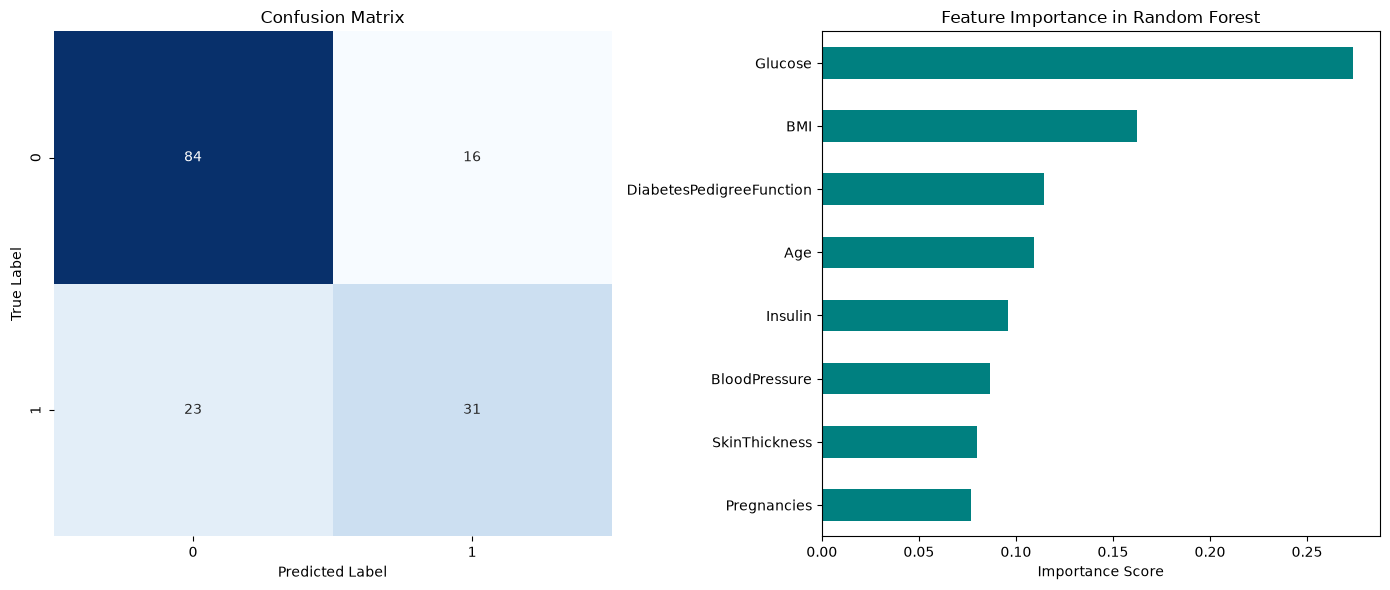

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Configuration de la figure avec deux graphiques côte à côte
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Graphique 1 : Matrice de confusion ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0])
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# --- Graphique 2 : Importance des variables (Feature Importances) ---
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importances.sort_values(ascending=True).plot(kind="barh", color="teal", ax=axes[1])
axes[1].set_title("Feature Importance in Random Forest")
axes[1].set_xlabel("Importance Score")

plt.tight_layout()
plt.show()

In [1]:
import joblib

# Sauvegarde du modèle Random Forest dans le dossier models/
joblib.dump(rf_model, "../models/diabetes_random_forest.pkl")

print("Modèle sauvegardé avec succès sous 'diabetes_random_forest.pkl' !")

NameError: name 'rf_model' is not defined